In [1]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import ISAInvariants
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import render_path

### Usage as a Decomposer

In [2]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 1.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = ISAInvariants(gate_set, costs, names, precompute_polytopes=1)
decomposer = GulpsDecomposer(isa=isa)

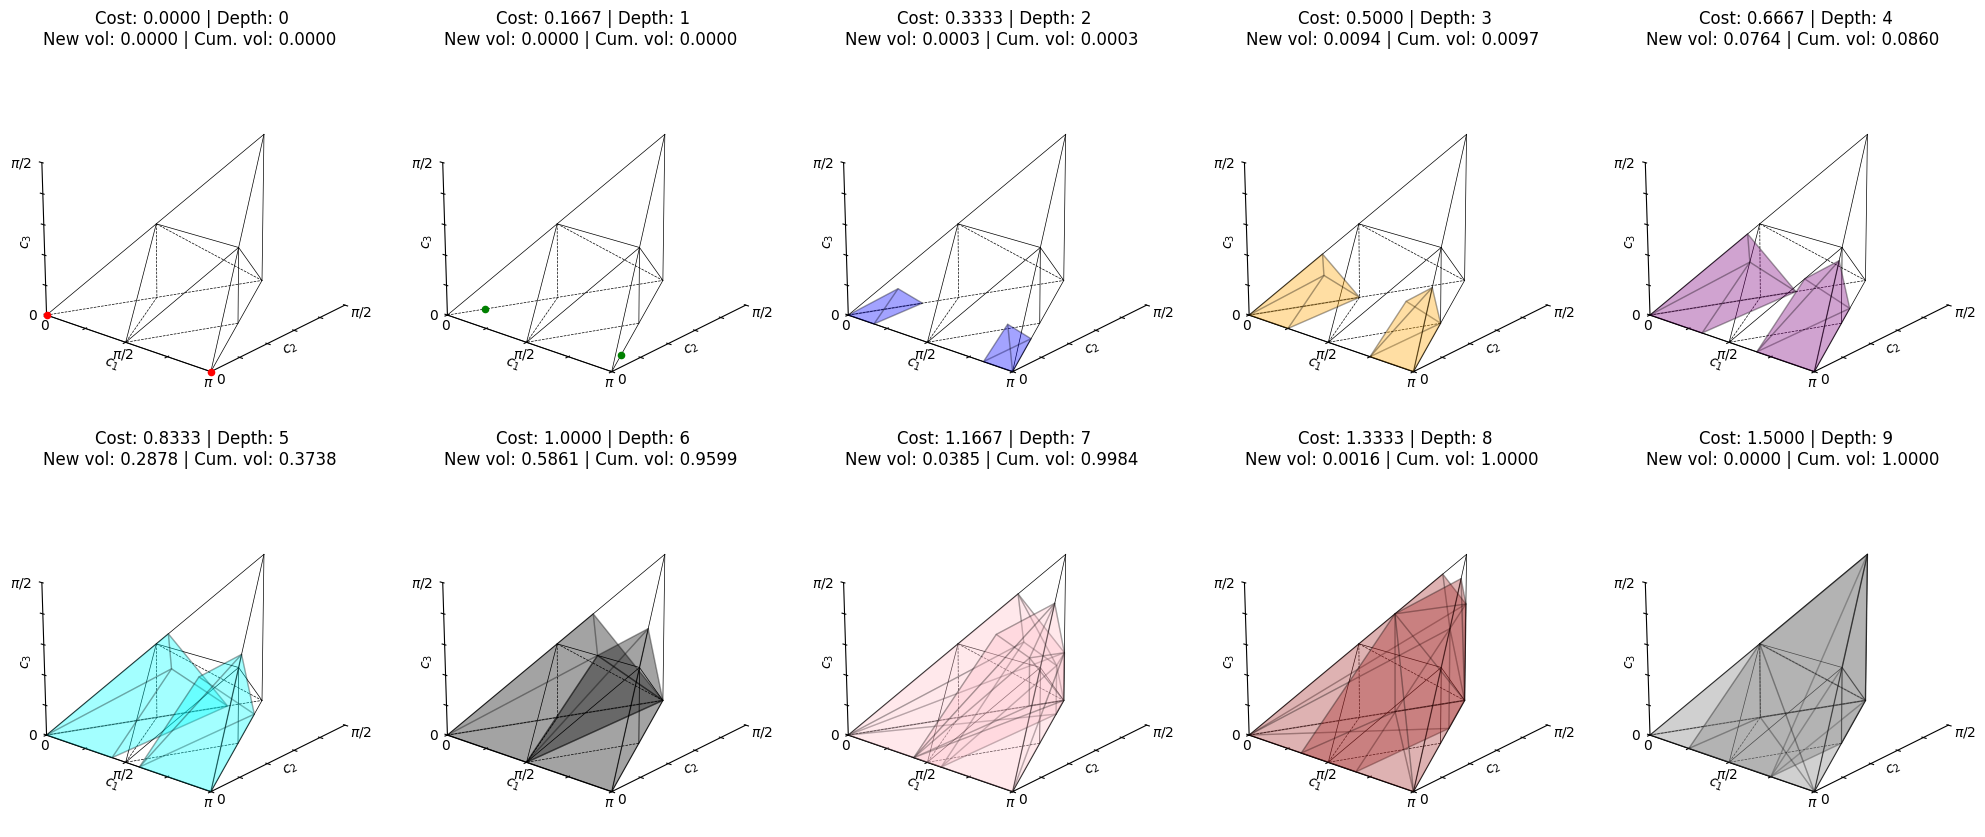

Coverage Set Statistics (Haar-averaged over SU(4))
Expected Cost:  0.928659
  → Average cost per random 2-qubit unitary

Expected Depth: 5.571953
  → Average number of 2-qubit gates


In [3]:
if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

In [4]:
logger.setLevel("INFO")
N = 1_000

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries: 100%|██████████| 1000/1000 [00:56<00:00, 17.62it/s]


✔ Completed 1000 successful runs (out of 1000)
  → Failures: 0
  → Median Fidelity: 1.0000000000000007
  → Mean Fidelity:   0.9999999999999761
  → Min Fidelity:    0.9999999999810371

Average phase durations:
  lp_sentence: 0.0022 s
    segments: 0.0517 s

  Total average time: 0.0539 s


In [5]:
decomposer._local_synthesis._cache.stats

{'hits': 375, 'misses': 4236, 'hit_rate': 0.08132726089785296, 'entries': 7}

In [6]:
# import cProfile, pstats

# pr = cProfile.Profile()
# pr.enable()

# # Python-heavy orchestration that calls jitted f
# for i in range(10):
#     decomposer(random_unitary(4, seed=i))


# pr.disable()
# pstats.Stats(pr).sort_stats("cumulative").print_stats(50)


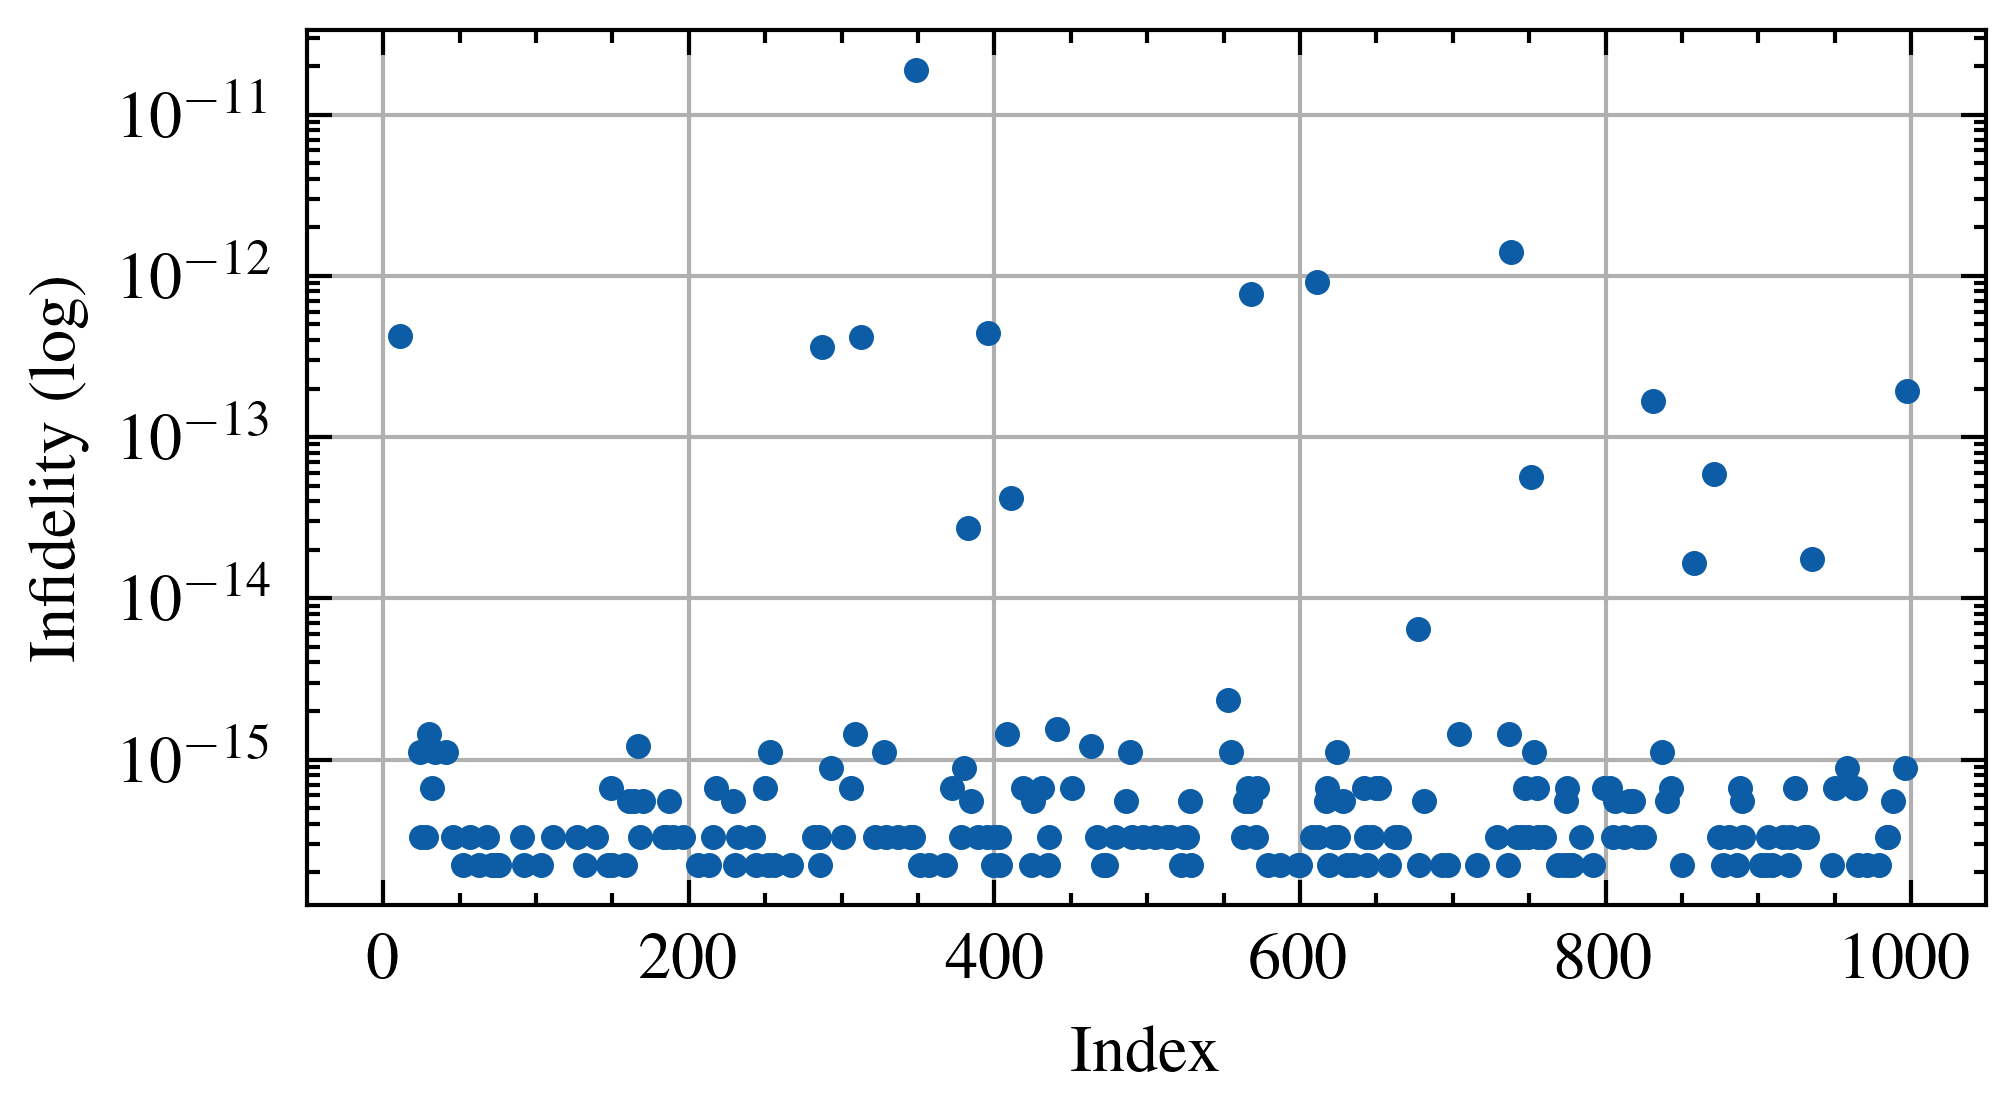

In [7]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

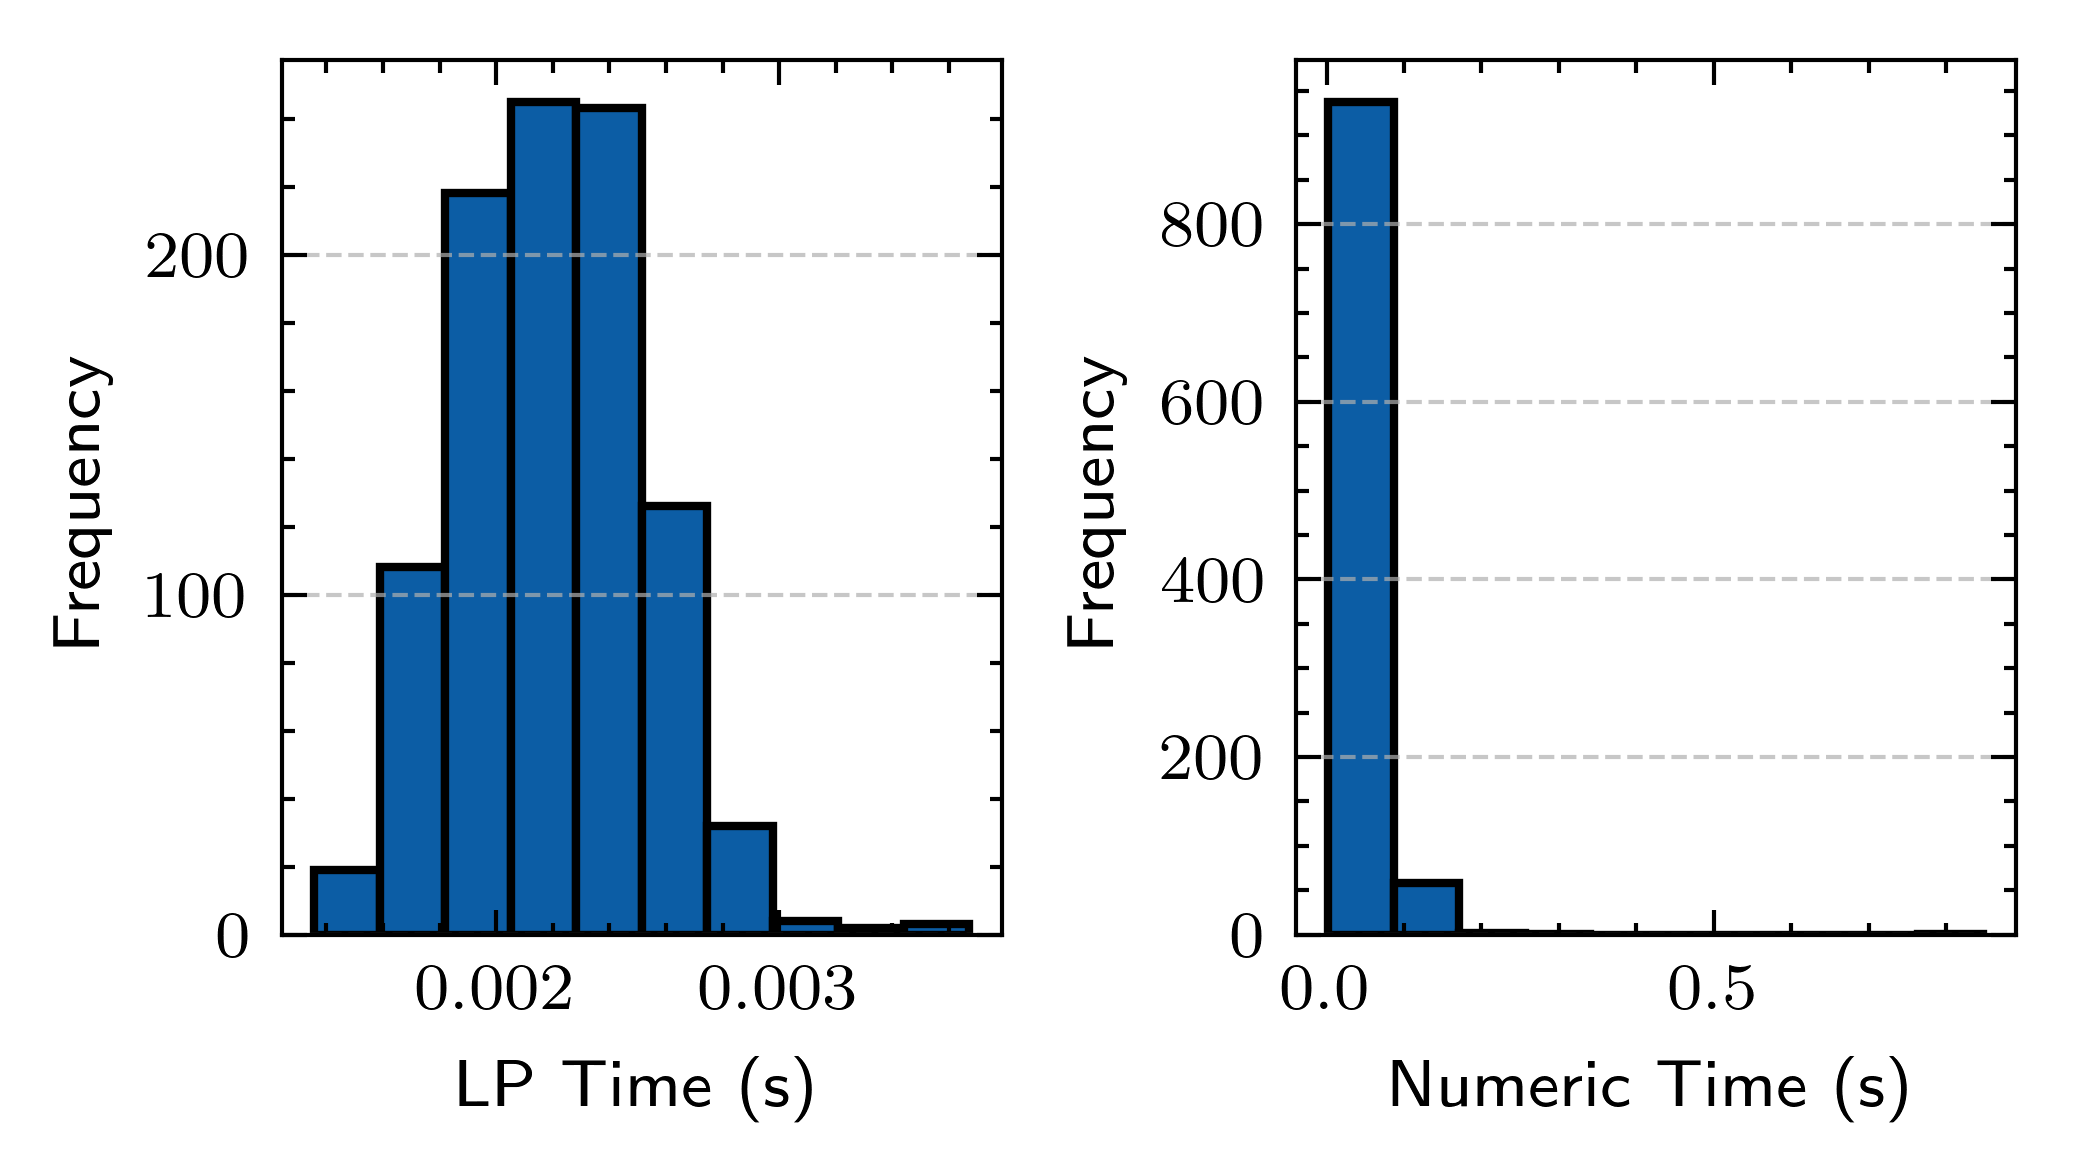

In [8]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()

In [9]:
i = 0

In [10]:
# generate random unitaries
# I want to check the rules for weyl to makhlin degeneracies
i += 1
U = random_unitary(4, seed=i)
# gi = GateInvariants.from_unitary(U)
gi = GateInvariants.from_weyl((1 - 0.3, 0.0, 0.3))
print(gi.weyl)
print(gi.rho_reflect.weyl)
print(gi.makhlin)
print(gi.rho_reflect.makhlin)

[0.7 0.  0.3]
[ 0.3  0.  -0.3]
[0.11936437851565791, 6.626054067407783e-18, 0.3819660112501053]
[0.11936437851565791, -6.626054067407783e-18, 0.3819660112501053]


<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

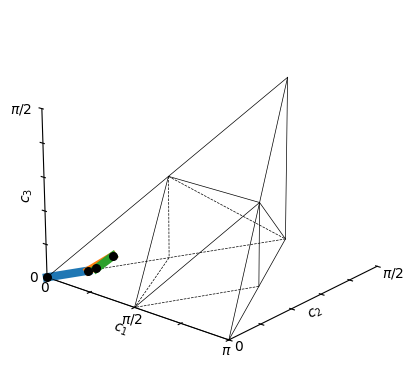

In [11]:
s, t = decomposer._best_decomposition(
    GateInvariants.from_unitary(random_unitary(4, seed=(i := i + 1)))
)
render_path(t)

<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

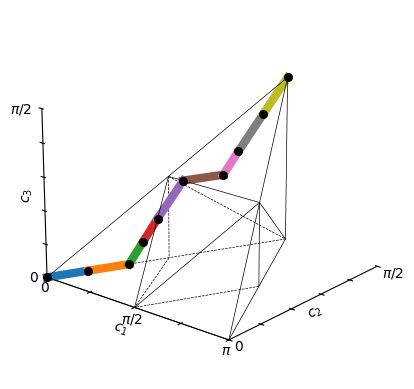

In [12]:
s, t = decomposer._best_decomposition(GateInvariants.from_unitary(SwapGate()))
render_path(t)